<a href="https://colab.research.google.com/github/AlexanderOlivera/Analisis-de-algoritmos/blob/main/Factorial_Iterativo_vs_Recursivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔁 Tarea: Factorial Iterativo vs Recursivo (Análisis experimental)

## 🎯 Objetivo
En este notebook vas a implementar dos versiones del factorial y comparar su comportamiento experimental:

- **Versión iterativa**
- **Versión recursiva**

Tu objetivo es:
1. Implementar correctamente ambos algoritmos.
2. Medir tiempos de ejecución para distintos tamaños de entrada `n`.
3. Visualizar gráficamente el rendimiento.
4. Identificar **la limitación práctica** de la versión recursiva (profundidad máxima de recursión).

> ⚠️ Importante: la notación asintótica debe deducirse en el **PDF** (análisis teórico).  
> Este notebook solo te da evidencia experimental.


In [ ]:
import time
import math
import sys
import matplotlib.pyplot as plt


## ✅ Reglas / recomendaciones para el experimento
- Usa `time.perf_counter()` para medir con mejor precisión.
- Ejecuta varias repeticiones y promedia.
- Considera que el factorial crece muy rápido: `n!` tiene muchos dígitos.
  - Por eso, para comparar tiempos del algoritmo (y no del tamaño del número), también mediremos una variante que solo haga multiplicaciones bajo módulo (ver más abajo).


# 🧩 Parte 1: Implementación (TU CÓDIGO)

Implementa:

- `factorial_iterativo(n)`
- `factorial_recursivo(n)`

Requisitos:
- Deben aceptar `n >= 0`.
- Deben manejar `n = 0` correctamente.
- Si `n < 0`, deben lanzar `ValueError`.


In [ ]:
#ITERATIVO
def factorial_iterativo(n: int) -> int:
  if n < 0:
    raise ValueError("n debe ser >= 0")
  resultado = 1
  for i in range(1, n + 1):
    resultado *= i
  return resultado


#RECURSIVO
def factorial_recursivo(n: int) -> int:
  if n < 0:
    raise ValueError("n debe ser >= 0")
  if n == 0:
    return 1
  return n * factorial_recursivo(n - 1)

## ✅ Prueba rápida (sanity check)
Ejecuta esta celda cuando termines tu implementación.


In [ ]:
def sanity_check():
    for n in range(0, 11):
        fi = factorial_iterativo(n)
        fr = factorial_recursivo(n)
        fm = math.factorial(n)
        if fi != fm or fr != fm:
            print(f"FAIL ❌ en n={n}")
            print("iterativo:", fi)
            print("recursivo:", fr)
            print("math.factorial:", fm)
            return
    print("OK ✅ Ambos algoritmos coinciden con math.factorial para n=0..10")

#Descomenta cuando implementes:
sanity_check()


OK ✅ Ambos algoritmos coinciden con math.factorial para n=0..10


# ⏱️ Parte 2: Medición de tiempos (factorial exacto)

Mediremos el tiempo de ejecución para distintos `n`.  
⚠️ Nota: al crecer `n`, también crece el costo de multiplicar enteros grandes, así que los tiempos pueden reflejar:
- costo del **algoritmo**
- y costo de **aritmética de enteros grandes** (Python usa enteros de precisión arbitraria)

Aun así, esta medición sirve para observar tendencias y comparar implementaciones.


In [ ]:
def medir_promedio(func, n, repeticiones=10):
    muestras = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        func(n)
        fin = time.perf_counter()
        muestras.append(fin - inicio)
    return sum(muestras) / repeticiones


In [ ]:
M = 10**9 + 7

def factorial_iterativo_mod(n):
    res = 1
    for i in range(1, n + 1):
        res = (res * i) % M
    return res

def factorial_recursivo_mod(n):
    if n == 0: return 1
    return (n * factorial_recursivo_mod(n - 1)) % M

## 2.1 Rango seguro inicial para graficar
Empieza con un rango moderado para evitar que la medición tarde demasiado.


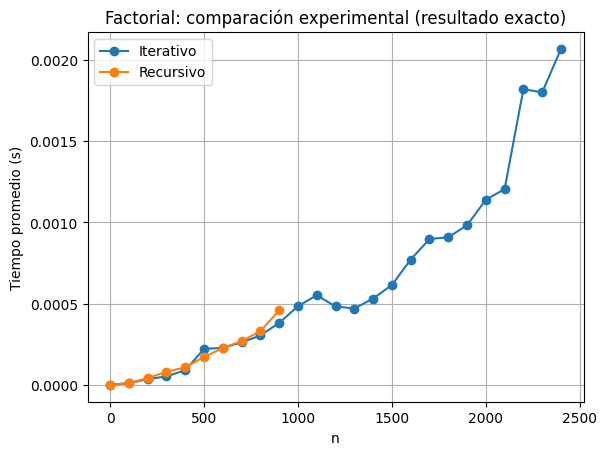

In [ ]:
# Ajusta el rango si tu equipo tarda demasiado
ns = list(range(0, 2500, 100))  # 0..2400

# Descomenta cuando implementes:
rep = 15
tiempos_iter = [medir_promedio(factorial_iterativo, n, rep) for n in ns]
tiempos_recur = []
for n in ns:
     try:
         tiempos_recur.append(medir_promedio(factorial_recursivo, n, rep))
     except RecursionError:
         tiempos_recur.append(float("nan"))
plt.figure()
plt.plot(ns, tiempos_iter, marker="o", label="Iterativo")
plt.plot(ns, tiempos_recur, marker="o", label="Recursivo")
plt.xlabel("n")
plt.ylabel("Tiempo promedio (s)")
plt.title("Factorial: comparación experimental (resultado exacto)")
plt.grid(True)
plt.legend()
plt.show()


# 🧱 Parte 3: ¿Cuándo deja de funcionar el recursivo?

Python tiene un **límite de recursión**.  
En esta sección vas a encontrar experimentalmente a partir de qué `n` tu implementación recursiva falla por `RecursionError`.


In [ ]:
print("Límite de recursión actual (sys.getrecursionlimit()):", sys.getrecursionlimit())


Límite de recursión actual (sys.getrecursionlimit()): 1000


## 3.1 Búsqueda del primer `n` que falla (recursivo)

Esta celda intenta ejecutar factorial recursivo con `n` creciente hasta encontrar el primer fallo.  
✅ Debes reportar en tus conclusiones:
- el valor aproximado de `n` donde ocurre el error
- por qué ocurre


In [ ]:
def encontrar_n_que_falla(max_n=2000):
    for n in range(1, max_n + 1):
        try:
            factorial_recursivo(n)
        except RecursionError:
            return n  # Retorna el primer valor que causó el error
    return None

n_fallo = encontrar_n_que_falla()
print(f"La recursión falló exactamente en n = {n_fallo}")

La recursión falló exactamente en n = 977


In [ ]:
def encontrar_n_falla_recursivo(max_n=5000, paso=10):
    """Busca el primer n donde factorial_recursivo lanza RecursionError."""
    ultimo_ok = None
    for n in range(0, max_n + 1, paso):
        try:
            factorial_recursivo(n)
            ultimo_ok = n
        except RecursionError:
            return ultimo_ok, n
    return ultimo_ok, None

# Descomenta cuando implementes:
ultimo_ok, primer_falla = encontrar_n_falla_recursivo(max_n=5000, paso=10)
print("Último n que funcionó (aprox):", ultimo_ok)
print("Primer n que falla (aprox):", primer_falla)

# Afinación (si quieres exactitud):
if primer_falla is not None:
     for n in range(max(0, primer_falla - 20), primer_falla + 1):
         try:
             factorial_recursivo(n)
         except RecursionError:
             print("Falla exacta en n =", n)
             break

Último n que funcionó (aprox): 970
Primer n que falla (aprox): 980
Falla exacta en n = 978


> ⚠️ Nota: **No cambies el límite de recursión** para “hacerlo funcionar más”.  
La intención es que observes la limitación real del enfoque recursivo en Python.


# 🧪 Parte 4 (opcional recomendado): comparar costo de control (módulo)

Para comparar mejor el costo del **control de flujo** (iteración vs recursión),
evitamos construir el entero gigante `n!` usando aritmética módulo `M`.

✅ Esto NO calcula el factorial exacto; es solo para medir rendimiento de estructura de control.


In [ ]:
MOD = 1_000_000_007

def factorial_iterativo_mod(n: int, mod: int = MOD) -> int:
    if n < 0:
        raise ValueError("n debe ser >= 0")
    acc = 1
    for k in range(2, n + 1):
        acc = (acc * k) % mod
    return acc

def factorial_recursivo_mod(n: int, mod: int = MOD) -> int:
    if n < 0:
        raise ValueError("n debe ser >= 0")
    if n <= 1:
        return 1
    return (n * factorial_recursivo_mod(n - 1, mod)) % mod


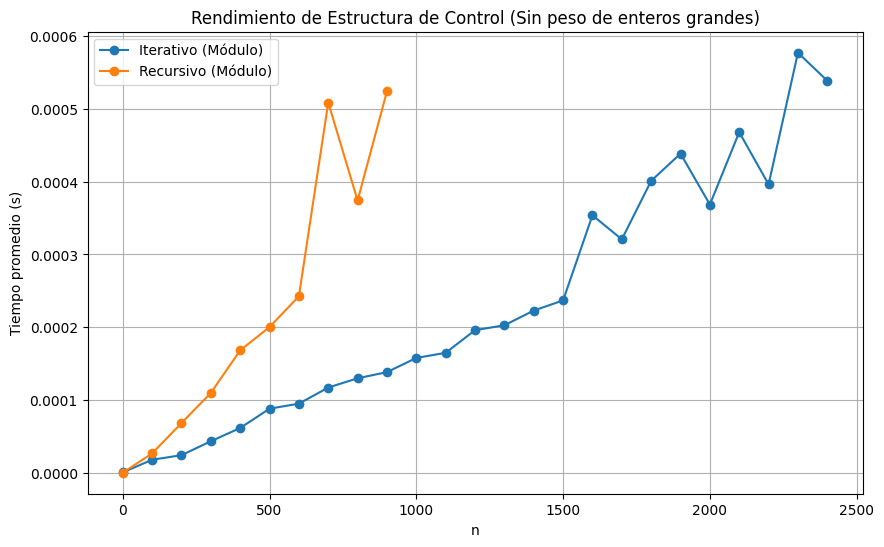

In [ ]:
ns_mod = list(range(0, 2500, 100))
rep = 15

tiempos_iter_mod = [medir_promedio(factorial_iterativo_mod, n, rep) for n in ns_mod]
tiempos_recur_mod = []

for n in ns_mod:
    try:
        tiempos_recur_mod.append(medir_promedio(factorial_recursivo_mod, n, rep))
    except RecursionError:
        tiempos_recur_mod.append(float("nan"))

plt.figure(figsize=(10, 6))
plt.plot(ns_mod, tiempos_iter_mod, label='Iterativo (Módulo)', marker='o')
plt.plot(ns_mod, tiempos_recur_mod, label='Recursivo (Módulo)', marker='o')

plt.title('Rendimiento de Estructura de Control (Sin peso de enteros grandes)')
plt.xlabel('n')
plt.ylabel('Tiempo promedio (s)')
plt.legend()
plt.grid(True)
plt.show()

## 4.1 Gráfica modular (iterativo vs recursivo)

⚠️ También puede fallar por `RecursionError` si `n` supera el límite.


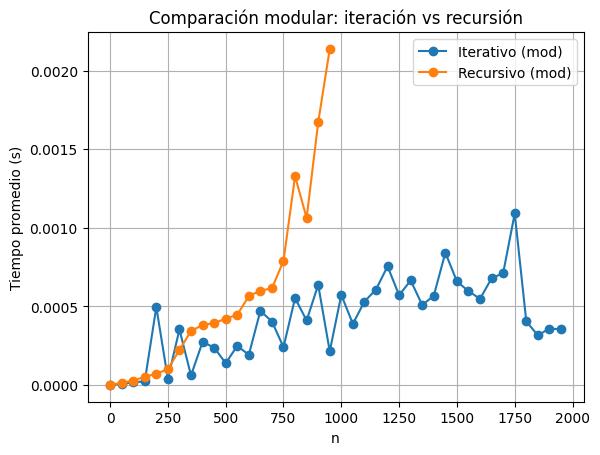

In [ ]:
ns_mod = list(range(0, 2000, 50))

# Descomenta cuando implementes:
rep = 20
t_iter_mod = [medir_promedio(lambda x: factorial_iterativo_mod(x), n, rep) for n in ns_mod]
t_recur_mod = []
for n in ns_mod:
     try:
         t_recur_mod.append(medir_promedio(lambda x: factorial_recursivo_mod(x), n, rep))
     except RecursionError:
         t_recur_mod.append(float("nan"))

plt.figure()
plt.plot(ns_mod, t_iter_mod, marker="o", label="Iterativo (mod)")
plt.plot(ns_mod, t_recur_mod, marker="o", label="Recursivo (mod)")
plt.xlabel("n")
plt.ylabel("Tiempo promedio (s)")
plt.title("Comparación modular: iteración vs recursión")
plt.grid(True)
plt.legend()
plt.show()

# ✅ Preguntas de reflexión (responder en el notebook)

**1. ¿En qué rango de `n` la versión recursiva deja de funcionar y por qué?**

   La función recursiva dejó de funcionar exactamente en n=978. Esto sucede porque Python tiene un límite de seguridad llamado sys.getrecursionlimit(), que por defecto suele ser 1000.

  Cada vez que la función se llama a sí misma, ocupa un "piso" en la pila de llamadas (call stack). Como el sistema ya está usando algunos pisos para otras funciones internas, cuando intenté calcular un factorial cerca de 1000, me quedé sin espacio y Python lanzó un RecursionError para evitar que el programa colapsara.


---


**2. ¿Observas diferencia de tiempo entre iterativo y recursivo antes de fallar?**

  La versión recursiva es más lenta que la iterativa.
  En las gráficas, la línea naranja (recursiva) siempre está por encima de la azul (iterativa). Esto se debe al "costo" extra que tiene la computadora para abrir, mantener y cerrar una función nueva por cada número del factorial, mientras que el bucle for es mucho más ligero y directo.


---


**3. ¿La tendencia experimental coincide con tu análisis teórico? Explica.**

  Coincide, en la versión con módulo (donde los números no crecen infinito), la gráfica es una línea recta, lo que confirma que ambos algoritmos tienen una complejidad de tiempo O(n). En la versión exacta, se nota una ligera curva hacia arriba porque, aunque el algoritmo sigue siendo lineal, a Python le cuesta más tiempo procesar multiplicaciones de números que tienen miles de dígitos.


---


**4. ¿Qué papel juega la pila de llamadas en el rendimiento y limitaciones?**
  En rendimiento hace que el algoritmo sea más lento porque tiene que gestionar mucha memoria extra para recordar cada llamada pendiente (espacio O(n)).
  En limitaciones es la que impone el límite físico, si la pila se llena, el programa truena. El método iterativo, en cambio, usa un espacio constante (O(1)) y por eso puede llegar a números mucho más grandes sin problemas.


---


**5. En un lenguaje con optimización de cola (TCO), ¿esperarías el mismo límite? ¿por qué?**

  El límite sería mucho mayor o inexistente. Con la Optimización de Llamada de Cola (TCO), el lenguaje recilcaria el mismo espacio en la pila en lugar de acumular pisos nuevos. Esto haria que la recursión funcionara igual de eficiente que un bucle, eliminando el riesgo del RecursionError por profundidad.

---

✅ **Recuerda:** la notación asintótica final se deduce en el PDF con sustitución + inducción.
